# 04 - Modelisation & Projections JO 2028 (YPerf)

Objectif: entrainer et evaluer un modele de prevision du nombre de medailles par (pays, sport) pour l'edition suivante, puis projeter les resultats pour **Los Angeles 2028**.

Demarche:
1. Validation **temporelle stricte** (on entraine sur le passe, on teste sur le futur).
2. Comparaison d'un **baseline** (derniere valeur observee) et d'une **Random Forest**.
3. Backtest sur plusieurs editions pour verifier la robustesse.
4. Analyse des variables importantes.
5. Projection 2028 a partir de la derniere edition disponible (2024).

## Setup

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data_prep import build_analytics_dataset
from src.features import build_feature_frame, build_supervised_dataset
from src.model import train_baseline, train_random_forest, extract_feature_importance, MODEL_FEATURES
from src.evaluation import temporal_split, evaluate, temporal_backtest
from src.predict import predict_next_edition
from src.noc import format_noc_label
from src.config import TARGET_COL
pd.set_option('display.max_columns', 40)

## 1) Construction du jeu supervise

On rejoue la chaine du notebook 03 via les modules `src/` pour disposer a la fois du `feature_frame` complet (utile pour l'inference 2028) et du `supervised` (entrainement).

In [2]:
analytics = build_analytics_dataset()
feature_frame = build_feature_frame(analytics)
supervised = build_supervised_dataset(feature_frame)
print('feature_frame:', feature_frame.shape, '| supervised:', supervised.shape)
print('editions:', sorted(supervised['Year'].unique())[-6:])

feature_frame: (26229, 17) | supervised: (22036, 17)
editions: [np.int64(2000), np.int64(2004), np.int64(2008), np.int64(2012), np.int64(2016), np.int64(2020)]


## 2) Validation temporelle stricte

On **n'utilise pas** de split aleatoire: cela creerait une fuite (des editions futures dans l'entrainement). On entraine sur `Year < derniere_edition` et on valide sur la derniere edition.

In [3]:
train_df, valid_df = temporal_split(supervised)
print('train annees:', train_df['Year'].min(), '->', train_df['Year'].max(), '| n =', len(train_df))
print('valid annee :', int(valid_df['Year'].iloc[0]), '| n =', len(valid_df))

train annees: 1896 -> 2016 | n = 20330
valid annee : 2020 | n = 1706


## 3) Entrainement: baseline vs Random Forest

- **Baseline** `LastValue`: predit que le pays refera exactement son score precedent. C'est un repere exigeant sur des donnees tres auto-correlees.
- **Random Forest**: encode `NOC`/`Sport` (one-hot) + features numeriques (lags, rolling, participation).

In [4]:
baseline = train_baseline(train_df)
rf = train_random_forest(train_df)

baseline_metrics = evaluate(baseline, valid_df)
rf_metrics = evaluate(rf, valid_df)
pd.DataFrame([baseline_metrics, rf_metrics])

,model,mae,rmse,n_samples,valid_year
0,baseline_last_value,0.4050,0.9069,1706,2020
1,random_forest,0.4192,0.8076,1706,2020


**Lecture**: on compare MAE (erreur absolue moyenne) et RMSE. Le modele retenu est celui qui bat le baseline sur l'edition de validation.

## 4) Backtest multi-editions

Une seule edition de test peut etre chanceuse. On rejoue l'evaluation sur plusieurs editions recentes avec une fenetre d'entrainement glissante.

In [5]:
years = sorted(supervised['Year'].unique())
test_years = years[-3:]
bt_baseline = temporal_backtest(supervised, train_baseline, test_years)
bt_rf = temporal_backtest(supervised, train_random_forest, test_years)
bt_baseline['model'] = 'baseline'
bt_rf['model'] = 'random_forest'
pd.concat([bt_baseline, bt_rf]).sort_values(['valid_year','model'])[['valid_year','model','mae','rmse','n_samples']]

,valid_year,model,mae,rmse,n_samples
0,2012,baseline,0.4258,1.0349,1618
0,2012,random_forest,0.4401,0.9964,1618
1,2016,baseline,0.4121,0.9772,1400
1,2016,random_forest,0.4174,0.8536,1400
2,2020,baseline,0.4050,0.9069,1706
2,2020,random_forest,0.4192,0.8076,1706


## 5) Variables les plus importantes

In [6]:
importance = extract_feature_importance(rf.estimator)
importance.head(12)

,feature,importance
0,medals,0.380081
1,medal_points,0.365999
2,medals_roll_3,0.044792
3,points_lag_1,0.038582
4,Year,0.023446
5,entries,0.021015
6,athletes,0.019417
7,entries_lag_1,0.017863
8,medals_lag_2,0.014407
9,medals_lag_1,0.012832


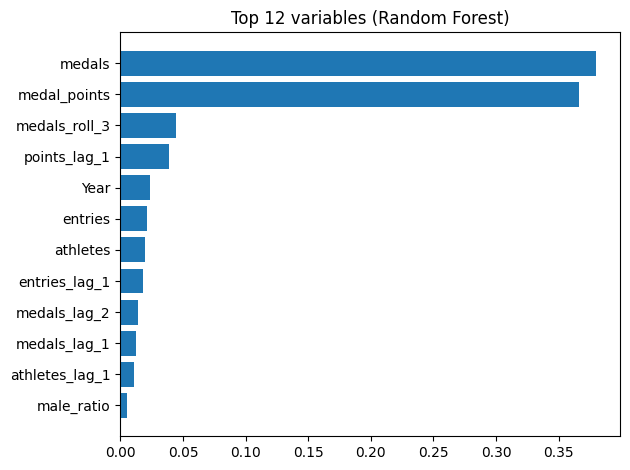

In [7]:
import matplotlib.pyplot as plt
top = importance.head(12).iloc[::-1]
plt.barh(top['feature'], top['importance'])
plt.title('Top 12 variables (Random Forest)')
plt.tight_layout(); plt.show()

## 6) Projection JO 2028

On applique le modele aux lignes de la **derniere edition disponible (2024)** uniquement, pour projeter l'edition suivante (2028), puis on agrege par pays.

In [8]:
source_year = int(feature_frame['Year'].max())
pred = predict_next_edition(rf.estimator, feature_frame, source_year=source_year)
proj_2028 = (
    pred.groupby('NOC', as_index=False)['predicted_medals_next_edition']
    .sum().rename(columns={'predicted_medals_next_edition':'medailles_projetees_2028'})
    .sort_values('medailles_projetees_2028', ascending=False)
)
proj_2028['pays'] = proj_2028['NOC'].map(format_noc_label)
print('edition source:', source_year, '-> cible 2028')
proj_2028.head(15)[['pays','medailles_projetees_2028']].reset_index(drop=True)

edition source: 2024 -> cible 2028


,pays,medailles_projetees_2028
0,USA - United States,110.741940
1,CHN - China,84.981381
2,GBR - United Kingdom,59.377064
3,AUS - Australia,56.980512
4,FRA - France,52.920003
5,JPN - Japan,50.507892
6,GER - Germany,41.169354
7,ITA - Italy,38.393461
8,NED - Netherlands,29.353857
9,CAN - Canada,27.602153


### Synthese & storytelling

- La Random Forest est comparee a un baseline exigeant via une **validation temporelle stricte** et un **backtest** multi-editions.
- Les variables dominantes confirment la forte **inertie historique** (lags de medailles) tout en integrant la dynamique de participation.
- Les projections 2028 par pays alimentent directement la page *Predictions 2028* de l'application Streamlit (meme code `src/`).

> Limite: le modele projette une tendance; il n'anticipe pas les ruptures (nouveaux sports LA2028, blessures, changements de reglement). A completer par un scenario optimiste/pessimiste dans le storytelling.